## 1. Environment Setup & Imports
This cell installs all necessary libraries (Albumentations, Real-ESRGAN, diffusers) and imports PyTorch, torchvision, and other data processing tools required for the model.


In [1]:
# --- STEP 1: INITIALIZE ENVIRONMENT ---
# We install required libraries using pip and import PyTorch and data processing tools.

# 1. Install required packages (like Super-Resolution)
!pip install -q albumentations==1.3.1
!pip install -q realesrgan basicsr diffusers transformers accelerate

import pandas as pd
import numpy as np
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torchvision.utils import save_image

from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 15.5 MB/s eta 0:00:00


## 2. Configuration & Hyperparameters
Here we define training hyperparameters (Learning Rate, Epochs, Batch Size) and set up the file paths for saving and loading our checkpoints during training. This is crucial for avoiding loss of progress.


In [2]:
# --- STEP 2: HYPERPARAMETERS & CONFIGURATION ---
# Configure learning rate, epochs, and save paths.

# set parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LEARNING_RATE = 5e-5    # Dropped for finer color adjustments
BATCH_SIZE = 16
NUM_WORKERS = 2 # Kaggle works fine with 2 multiprocessing workers
IMAGE_SIZE = 256
CHANNELS_IMG = 3
L1_LAMBDA = 5           # Reduced further to prioritize adversarial vibrant colors
VGG_LAMBDA = 20         # Disabled to prevent muddy/average color blending
LAMBDA_FM = 10           # Disabled to prioritize standard GAN loss for color
NUM_EPOCHS = 400        # More training time with new schedule
SAVE_PER_EPOCHS = 5
SAVE_MODEL = True

# IMPORTANT: Set to False to retrain from scratch with new loss weights
LOAD_MODEL = True

import os
import shutil

# ==========================================
# KAGGLE PATHS (CRITICAL FOR SAVING WORK)
# ==========================================
# Save directly to Kaggle's working directory. 
# To keep these files permanently, you MUST click "Save Version" -> "Save & Run All (Commit)"
SAVE_PATH = '/kaggle/working/cGAN_Colorization_Checkpoints/'
os.makedirs(SAVE_PATH, exist_ok=True)

# =========================================================
# UPDATE THIS PATH TO MATCH YOUR VERSION 1 OUTPUT DIRECTORY
# =========================================================
# Updated to match the folder name in your sidebar!
PREVIOUS_VERSION_DIR = '/kaggle/input/notebooks/impartiall/sketchcolured/cGAN_Colorization_Checkpoints'

# Copy the old checkpoints into the working directory so we can resume saving over them
if LOAD_MODEL and os.path.exists(PREVIOUS_VERSION_DIR) and not os.path.exists(os.path.join(SAVE_PATH, 'gen.pth.tar')):
    print("Copying checkpoints from previous version...")
    try:
        shutil.copy(os.path.join(PREVIOUS_VERSION_DIR, 'gen.pth.tar'), SAVE_PATH)
        shutil.copy(os.path.join(PREVIOUS_VERSION_DIR, 'disc.pth.tar'), SAVE_PATH)
        print("Success! Checkpoints copied.")
    except Exception as e:
        print(f"Failed to copy. Make sure the PREVIOUS_VERSION_DIR path is correct. Error: {e}")

# Save checkpoints
CHECKPOINT_DISC = os.path.join(SAVE_PATH, 'disc.pth.tar')
CHECKPOINT_GEN = os.path.join(SAVE_PATH, 'gen.pth.tar')
FINAL_MODEL = os.path.join(SAVE_PATH, 'generator.pth')

# Read datasets directly from Kaggle Input
TRAIN_DIR = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train'
VAL_DIR = '/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val'


Copying checkpoints from previous version...
Success! Checkpoints copied.


## 3. Utility Functions for Training
These helper functions are used to save checkpoints during training, load checkpoints to resume training, and save sample colorized images periodically to monitor the generator's progress.


In [3]:
# --- STEP 3: UTILITY FUNCTIONS ---
# Helper functions for saving/loading checkpoints and evaluating model output.

def save_some_examples(gen, val_loader, epoch, folder):
    x, y = next(iter(val_loader))
    x, y = x.to(DEVICE),y.to(DEVICE)
    # gen.eval()  # Keep dropout active
    with torch.no_grad():
        y_fake = gen(x)
        y_fake = y_fake * .5 + .5 # remove normalization
        save_image(y_fake, folder + f'/y_gen_{epoch}.png')
        if epoch == 0:
            # only the first epoch will save label and input sketch
            save_image(y * .5 + .5, folder+ f'/label_{epoch}.png')
            save_image(x * .5 + .5, folder + f'/input_{epoch}.png')
    gen.train()

def save_checkpoint(model, optimizer, filename='my_checkpoint.pth.tar', epoch=0):
    print(f'=> Saving checkpoint at epoch {epoch}')
    checkpoint = {
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch
    }
    torch.save(checkpoint, filename)

def load_checkpoint(checkpoint_file, model, optimizer, lr):
    print('=> Loading checkpoint')
    checkpoint = torch.load(checkpoint_file, map_location=DEVICE)
    # load saved checkpoint
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    # Return the saved epoch so we can resume from it
    return checkpoint.get('epoch', 0)


## 4. Building the Discriminator (Part 1/2: CNN Block)
Our Discriminator is built using Convolutional Neural Networks. This `CNNBlock` consists of Spectral Normalization (which stabilizes GAN training), Instance Normalization, and a LeakyReLU activation.


In [4]:
# --- STEP 4a: CNN BLOCK ---
# A reusable CNN building block with Spectral Normalization for stability in GAN training.

# CNN block will be used repeatly later
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.utils.spectral_norm(
                nn.Conv2d(in_channels, out_channels, 4, stride, bias=False, padding_mode='reflect')
            ),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.conv(x)


## 4. Building the Discriminator (Part 1/2: CNN Block)
Our Discriminator is built using Convolutional Neural Networks. This `CNNBlock` consists of Spectral Normalization (which stabilizes GAN training), Instance Normalization, and a LeakyReLU activation.


In [5]:
# --- STEP 4a: CNN BLOCK ---
# A reusable CNN building block with Spectral Normalization for stability in GAN training.

# Discriminator with intermediate feature extraction for Feature Matching Loss
class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels*2, features[0], kernel_size=4, stride=2, padding=1, padding_mode='reflect'),
            nn.LeakyReLU(.2)
        )
        
        # Build layers as a ModuleList so we can extract intermediate features
        self.layers = nn.ModuleList()
        in_channels = features[0]
        for feature in features[1:]:
            self.layers.append(
                CNNBlock(in_channels, feature, stride=1 if feature == features[-1] else 2),
            )
            in_channels = feature
            
        # Final prediction layer
        self.final = nn.Conv2d(in_channels, 1, kernel_size=4, stride=1, padding=1, padding_mode='reflect')
        
    def forward(self, x, y):
        x = torch.cat([x, y], dim=1)
        x = self.initial(x)
        
        # Collect intermediate features for feature matching
        features = [x]
        for layer in self.layers:
            x = layer(x)
            features.append(x)
        
        return self.final(x), features


### 5.1 Discriminator Output Test
Let's run a dummy tensor through our Discriminator to verify it outputs the correct shapes without crashing.


In [6]:
# Quick test to ensure Discriminator produces the expected output dimensions.

# test the output of discriminator
x = torch.randn((1,3,256,256))
y = torch.randn((1,3,256,256))
model = Discriminator()
preds, feats = model(x, y)
print(f"Disc output: {preds.shape}, Feature maps: {len(feats)}")


Disc output: torch.Size([1, 1, 26, 26]), Feature maps: 4


## 6. Building the Generator (Part 1/3: U-Net Block)
This standard convolutional `Block` is used for both downsampling (Encoder) and upsampling (Decoder) in our Generator model. It features optional Dropout to introduce variance and Instance Normalization.


In [7]:
# --- STEP 5a: GENERATOR BLOCK ---
# A reusable block for the Generator's Encoder (downsampling) and Decoder (upsampling).

# block will be use repeatly later
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, act='relu', use_dropout=False):
        super().__init__()
        self.conv = nn.Sequential(
            # the block will be use on both encoder (down=True) and decoder (down=False)
            nn.Conv2d(in_channels, out_channels, 4,2,1,bias=False, padding_mode='reflect')
            if down
            else nn.ConvTranspose2d(in_channels, out_channels, 4,2,1, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU() if act == 'relu' else nn.LeakyReLU(.2)
        )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(.5)
    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


## 7. Building the Generator (Part 2/3: Attention Gates)
Attention gates allow the Generator to focus on relevant spatial features in the image (like lines and boundaries in the sketch) while ignoring irrelevant regions. This dramatically improves coloring precision.


In [8]:
# --- STEP 5b: ATTENTION GATES ---
# Helps the decoder focus on important features from the encoder via skip connections.

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.InstanceNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.InstanceNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.InstanceNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


## 7. Building the Generator (Part 2/3: Attention Gates)
Attention gates allow the Generator to focus on relevant spatial features in the image (like lines and boundaries in the sketch) while ignoring irrelevant regions. This dramatically improves coloring precision.


In [9]:
# --- STEP 5b: ATTENTION GATES ---
# Helps the decoder focus on important features from the encoder via skip connections.

class Generator(nn.Module):
    def __init__(self, in_channels=3, features=64):
        super().__init__()
        # Encoder
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4,2,1, padding_mode='reflect'),
            nn.LeakyReLU(.2),
        )
        self.down1 = Block(features, features*2, down=True,act='leaky',use_dropout=False) #64
        self.down2 = Block(features*2, features*4, down=True,act='leaky',use_dropout=False) #32
        self.down3 = Block(features*4, features*8, down=True,act='leaky',use_dropout=False) #16
        self.down4 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #8
        self.down5 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #4
        self.down6 = Block(features*8, features*8, down=True,act='leaky',use_dropout=False) #2
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4,2,1,padding_mode='reflect'),
            nn.ReLU(), # 1x1
        )
        
        # Attention gates for each skip connection
        self.attn7 = AttentionGate(features*8, features*8, features*4)
        self.attn6 = AttentionGate(features*8, features*8, features*4)
        self.attn5 = AttentionGate(features*8, features*8, features*4)
        self.attn4 = AttentionGate(features*8, features*8, features*4)
        self.attn3 = AttentionGate(features*4, features*4, features*2)
        self.attn2 = AttentionGate(features*2, features*2, features)
        self.attn1 = AttentionGate(features, features, features//2)
        
        # Decoder
        self.up1 = Block(features*8, features*8, down=False,act='relu',use_dropout=True)
        self.up2 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=True)
        self.up3 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=True)
        self.up4 = Block(features*8*2, features*8, down=False,act='relu',use_dropout=False)
        self.up5 = Block(features*8*2, features*4, down=False,act='relu',use_dropout=False)
        self.up6 = Block(features*4*2, features*2, down=False,act='relu',use_dropout=False)
        self.up7 = Block(features*2*2, features, down=False,act='relu',use_dropout=False)
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features*2, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        # Encoder
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)
        bottleneck = self.bottleneck(d7)
        
        # Decoder with gated skip connections
        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, self.attn7(u1, d7)], 1))
        u3 = self.up3(torch.cat([u2, self.attn6(u2, d6)], 1))
        u4 = self.up4(torch.cat([u3, self.attn5(u3, d5)], 1))
        u5 = self.up5(torch.cat([u4, self.attn4(u4, d4)], 1))
        u6 = self.up6(torch.cat([u5, self.attn3(u5, d3)], 1))
        u7 = self.up7(torch.cat([u6, self.attn2(u6, d2)], 1))
        return self.final_up(torch.cat([u7, self.attn1(u7, d1)], 1))


### 8.1 Generator Output Test
Testing the Generator with a random tensor to ensure it outputs a valid image batch tensor.


In [10]:
# Quick test to guarantee the Generator produces an image of dimension [Batch, 3, 256, 256].

# test the output of Generator
x = torch.randn((1,3,256,256))
model = Generator(in_channels=3, features=64)
preds = model(x)
print(preds.shape)


torch.Size([1, 3, 256, 256])


## 9. Data Augmentation
Neural networks need diverse data to learn effectively. Here we apply random rotations, crops, and flips. We also apply slight color variations to the target images so the model understands there isn't just *one* correct color scheme.


In [11]:
# --- STEP 6: DATA AUGMENTATION ---
# Applies resizing, cropping, and color jitter to augment the training data.

# Data Augmentation
class Transforms():
    def __init__(self):
        # use on both sketchs and colored images
        self.both_transform = A.Compose([
            A.Resize(width=286, height=286),
            A.RandomCrop(width=256, height=256),
            A.HorizontalFlip(p=.5),
            A.Rotate(limit=15, p=.5)
        ],additional_targets={'image0':'image'})
        
        # use on sketchs only — NO ColorJitter (keep sketches clean B&W)
        self.transform_only_input = A.Compose([
            A.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5], max_pixel_value=255.0),
            ToTensorV2(),
        ])
        
        # use on colored images — light color augmentation teaches the
        # generator that multiple valid colorizations exist for one sketch
        self.transform_only_mask = A.Compose([
            A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.2, hue=0.05, p=0.5),
            A.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5], max_pixel_value=255.0),
            ToTensorV2(),
        ])


## 10. PyTorch Dataset Loader
This Custom Dataset class reads the paired image files from the folder (which contain both the sketch and the color image side-by-side), splits them in half, applies augmentations, and yields them as tensors.


In [12]:
# --- STEP 7: DATASET DEFINITION ---
# Reads image pairs from the directory, splits them into sketch/color, and applies transforms.

# Sketchs and Colored Image dataset
class AnimeDataset(Dataset):
    def __init__(self,root_dir,transforms):
        self.root_dir = root_dir
        self.list_files = os.listdir(self.root_dir)
        self.transform = transforms
    def __len__(self):
        return len(self.list_files)
    def __getitem__(self, index):
        # read image file
        img_file = self.list_files[index]
        img_path = os.path.join(self.root_dir, img_file)
        image = np.array(Image.open(img_path))
        
        # divide image into sketchs and colored_imgs, right is sketch and left is colored images
        sketchs = image[:,image.shape[1]//2:,:]
        colored_imgs = image[:,:image.shape[1]//2,:]
        
        # data augmentation on both sketchs and colored_imgs
        augmentations = self.transform.both_transform(image=sketchs, image0=colored_imgs)
        sketchs, colored_imgs = augmentations['image'], augmentations['image0']
        
        # conduct data augmentation respectively
        sketchs = self.transform.transform_only_input(image=sketchs)['image']
        colored_imgs = self.transform.transform_only_mask(image=colored_imgs)['image']
        return sketchs, colored_imgs


## 11. Custom Loss Functions
To generate realistic colors, a standard GAN loss isn't enough. We define extra constraints: VGGLoss (Perceptual matching), Feature Matching Loss (matching intermediate patterns), and Saturation Loss.


In [13]:
# --- STEP 8: LOSS FUNCTIONS ---
# VGG Loss (Perceptual), Feature Matching Loss, and Saturation Loss to improve image quality.

import os
import torch

from torchvision.models import vgg19, VGG19_Weights

class VGGLoss(nn.Module):
    """Multi-scale VGG perceptual loss.
    Extracts features at relu1_2, relu2_2, relu3_4, relu4_4, relu5_4
    so the generator is penalized at BOTH low-level color/texture AND
    high-level semantic levels, preventing mode collapse to a single hue.
    """
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features.eval().to(DEVICE)
        # Slice VGG at multiple depths
        self.slice1 = nn.Sequential(*list(vgg[:4]))   # relu1_2 — color
        self.slice2 = nn.Sequential(*list(vgg[4:9]))   # relu2_2 — texture
        self.slice3 = nn.Sequential(*list(vgg[9:18]))  # relu3_4 — patterns
        self.slice4 = nn.Sequential(*list(vgg[18:27])) # relu4_4 — structure
        self.slice5 = nn.Sequential(*list(vgg[27:36])) # relu5_4 — semantics
        
        for param in self.parameters():
            param.requires_grad = False
        
        self.loss = nn.L1Loss()
        # Weights: emphasize early layers for color
        self.weights = [1.0, 1.0, 1.0, 1.0, 1.0]

    def forward(self, input, target):
        total_loss = 0
        x, y = input, target
        for i, slicer in enumerate([self.slice1, self.slice2, self.slice3, self.slice4, self.slice5]):
            x = slicer(x)
            y = slicer(y)
            total_loss += self.weights[i] * self.loss(x, y)
        return total_loss


def feature_matching_loss(real_features, fake_features):
    """Feature Matching Loss: penalize generator for not matching
    the distribution of discriminator's intermediate features on real data.
    This is the most effective anti-mode-collapse technique (Salimans et al. 2016).
    """
    loss = 0
    for real_feat, fake_feat in zip(real_features, fake_features):
        loss += F.l1_loss(fake_feat, real_feat.detach())
    return loss / len(real_features)

class SaturationLoss(nn.Module):
    """Penalizes desaturated/grayish outputs.
    Converts to HSV and pushes saturation channel higher."""
    def __init__(self):
        super().__init__()

    def rgb_to_saturation(self, img):
        # img is in [-1, 1], convert to [0, 1]
        img = img * 0.5 + 0.5
        max_rgb, _ = img.max(dim=1, keepdim=True)
        min_rgb, _ = img.min(dim=1, keepdim=True)
        chroma = max_rgb - min_rgb
        # Saturation = chroma / max (avoid div by zero)
        saturation = chroma / (max_rgb + 1e-8)
        return saturation

    def forward(self, fake, real):
        sat_fake = self.rgb_to_saturation(fake)
        sat_real = self.rgb_to_saturation(real)
        # Penalize when fake is less saturated than real
        return F.relu(sat_real - sat_fake).mean()



## 12. Training Loop Step
This function executes exactly one epoch of training. It calculates the discriminator and generator losses and applies backpropagation using `torch.cuda.amp.autocast()` to optimize memory usage.


In [14]:
# --- STEP 9: TRAINING STEP ---
# Executes one epoch of training, optimizing both Generaator and Discriminator alternately.

def train_fn(disc, gen, loader, opt_disc, opt_gen, l1, bce, perceptual, sat_loss, g_scaler, d_scaler):
    loop = tqdm(loader, leave=True)
    for idx, (x, y) in enumerate(loop):
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # ---------- Train Discriminator ----------
        with torch.cuda.amp.autocast():
            y_fake = gen(x)
            
            # Add small noise to discriminator inputs for regularization
            noise_strength = 0.05
            x_noisy = x + noise_strength * torch.randn_like(x)
            y_noisy = y + noise_strength * torch.randn_like(y)
            
            D_real, real_features = disc(x_noisy, y_noisy)
            D_fake, _ = disc(x_noisy, y_fake.detach())
            
            # One-sided label smoothing: real=0.9 instead of 1.0
            # Prevents discriminator overconfidence -> better gradients for G
            D_real_loss = bce(D_real, torch.ones_like(D_real) * 0.9)
            D_fake_loss = bce(D_fake, torch.zeros_like(D_fake))
            D_loss = (D_real_loss + D_fake_loss) / 2
            
        disc.zero_grad()
        d_scaler.scale(D_loss).backward()
        d_scaler.step(opt_disc)
        d_scaler.update()
        
        # ---------- Train Generator ----------
        with torch.cuda.amp.autocast():
            D_fake, fake_features = disc(x, y_fake)
            
            G_fake_loss = bce(D_fake, torch.ones_like(D_fake))
            L1 = l1(y_fake, y) * L1_LAMBDA
            
            # Optimizations: Only calculate heavy losses if their lambda is > 0
            p_loss = 0
            if VGG_LAMBDA > 0:
                p_loss = perceptual(y_fake, y) * VGG_LAMBDA
                
            fm_loss = 0
            if LAMBDA_FM > 0:
                _, real_features_for_fm = disc(x, y)
                fm_loss = feature_matching_loss(real_features_for_fm, fake_features) * LAMBDA_FM
            
            # Saturation loss — penalizes washed-out colors
            s_loss = sat_loss(y_fake, y) * 5.0
            
            G_loss = G_fake_loss + L1 + p_loss + fm_loss + s_loss
            
        opt_gen.zero_grad()
        g_scaler.scale(G_loss).backward()
        g_scaler.step(opt_gen)
        g_scaler.update()
        
        if idx % 100 == 0:
            # We use an inline safe check for .item() since p_loss and fm_loss might just be integers (0) now
            val_L1 = L1.item() if hasattr(L1, 'item') else L1
            val_p = p_loss.item() if hasattr(p_loss, 'item') else p_loss
            val_fm = fm_loss.item() if hasattr(fm_loss, 'item') else fm_loss
            
            loop.set_postfix(D=D_loss.item(), G=G_loss.item(), L1=val_L1, FM=val_fm, SAT=s_loss.item())


## 3. Utility Functions for Training
These helper functions are used to save checkpoints during training, load checkpoints to resume training, and save sample colorized images periodically to monitor the generator's progress.


In [15]:
# --- STEP 3: UTILITY FUNCTIONS ---
# Helper functions for saving/loading checkpoints and evaluating model output.

def run():
    # model
    disc = Discriminator(in_channels=3).to(DEVICE)
    gen = Generator(in_channels=3).to(DEVICE)
    # optimizer
    opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(.5, .999))
    opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(.5, .999))
    
    # Flat + Linear Decay schedule: constant LR for first half, then linear decay to 0
    # Much better than CosineAnnealing for GANs which kills LR too early
    decay_start = NUM_EPOCHS // 2
    def lr_lambda(epoch):
        if epoch < decay_start:
            return 1.0
        return 1.0 - (epoch - decay_start) / (NUM_EPOCHS - decay_start)
    
    scheduler_disc = optim.lr_scheduler.LambdaLR(opt_disc, lr_lambda)
    scheduler_gen = optim.lr_scheduler.LambdaLR(opt_gen, lr_lambda)
    
    # loss
    BCE = nn.BCEWithLogitsLoss()
    L1_LOSS = nn.L1Loss()
    VGG_LOSS = VGGLoss()
    SAT_LOSS = SaturationLoss()    # <-- NEW
    
    start_epoch = 0
    
    # Auto-resume logic
    if LOAD_MODEL and os.path.exists(CHECKPOINT_GEN) and os.path.exists(CHECKPOINT_DISC):
        print(f"[*] Found checkpoints. Auto-resuming...")
        start_epoch = load_checkpoint(CHECKPOINT_GEN, gen, opt_gen, LEARNING_RATE) + 1
        load_checkpoint(CHECKPOINT_DISC, disc, opt_disc, LEARNING_RATE)
        
        # Fast-forward the schedulers to match the resumed epoch
        for _ in range(start_epoch):
            scheduler_disc.step()
            scheduler_gen.step()
    else:
        print("[*] Starting training from scratch (Epoch 0).")
    
    # train dataset
    transforms = Transforms()
    train_dataset = AnimeDataset(root_dir=TRAIN_DIR, transforms=transforms)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    g_scaler = torch.cuda.amp.GradScaler()
    d_scaler = torch.cuda.amp.GradScaler()
    
    # val dataset
    val_dataset = AnimeDataset(root_dir=VAL_DIR, transforms=transforms)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    if not os.path.exists('evaluation/'):
        os.makedirs('evaluation/')
        
    # Training loop
    for epoch in range(start_epoch, NUM_EPOCHS):
        cur_lr = opt_gen.param_groups[0]['lr']
        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | LR: {cur_lr:.6f}")
        train_fn(disc, gen, train_loader, opt_disc, opt_gen, L1_LOSS, BCE, VGG_LOSS, SAT_LOSS, g_scaler, d_scaler)    # <-- UPDATED
        
        # Step Schedulers
        scheduler_disc.step()
        scheduler_gen.step()
        
        # save model weight per SAVE_PER_EPOCHS
        if SAVE_MODEL and epoch % SAVE_PER_EPOCHS == 0:
            save_checkpoint(gen, opt_gen, filename=CHECKPOINT_GEN, epoch=epoch)
            save_checkpoint(disc, opt_disc, filename=CHECKPOINT_DISC, epoch=epoch)
        save_some_examples(gen, val_loader, epoch, folder='evaluation')

    torch.save(gen.state_dict(), FINAL_MODEL)
    print("Training complete! Final model saved.")


### 13.1 Start Training
Executes the `run()` function to start model training.


In [16]:
# Initiates the training process.

run()


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 179MB/s]


[*] Found checkpoints. Auto-resuming...
=> Loading checkpoint
=> Loading checkpoint


/tmp/ipykernel_23/754176112.py:36: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_disc.step()
/tmp/ipykernel_23/754176112.py:37: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_gen.step()
/tmp/ipykernel_23/754176112.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. P

Epoch [296/400] | LR: 0.000026


...

Epoch [398/400] | LR: 0.000001


100%|██████████| 889/889 [06:40<00:00,  2.22it/s, D=0.22, FM=2.71, G=40.7, L1=1.19, SAT=0.317]


Epoch [399/400] | LR: 0.000000


100%|██████████| 889/889 [06:42<00:00,  2.21it/s, D=0.259, FM=2.62, G=38.2, L1=1.07, SAT=0.239]


Training complete! Final model saved.


## 14. Evaluation Extraction
Once training finishes or halts, we load the sample images saved to the evaluation folder.


In [17]:
# Consolidates all generated sample images from the evaluation folder.

# save gen sample image into a list
imgs = []
for i in os.listdir('./evaluation'):
    if i[:5] == 'y_gen':
        img = plt.imread(os.path.join('./evaluation',i))
        imgs.append(img)


### 14.1 Plot Grid of Outputs
Plots the extracted evaluation images using matplotlib.


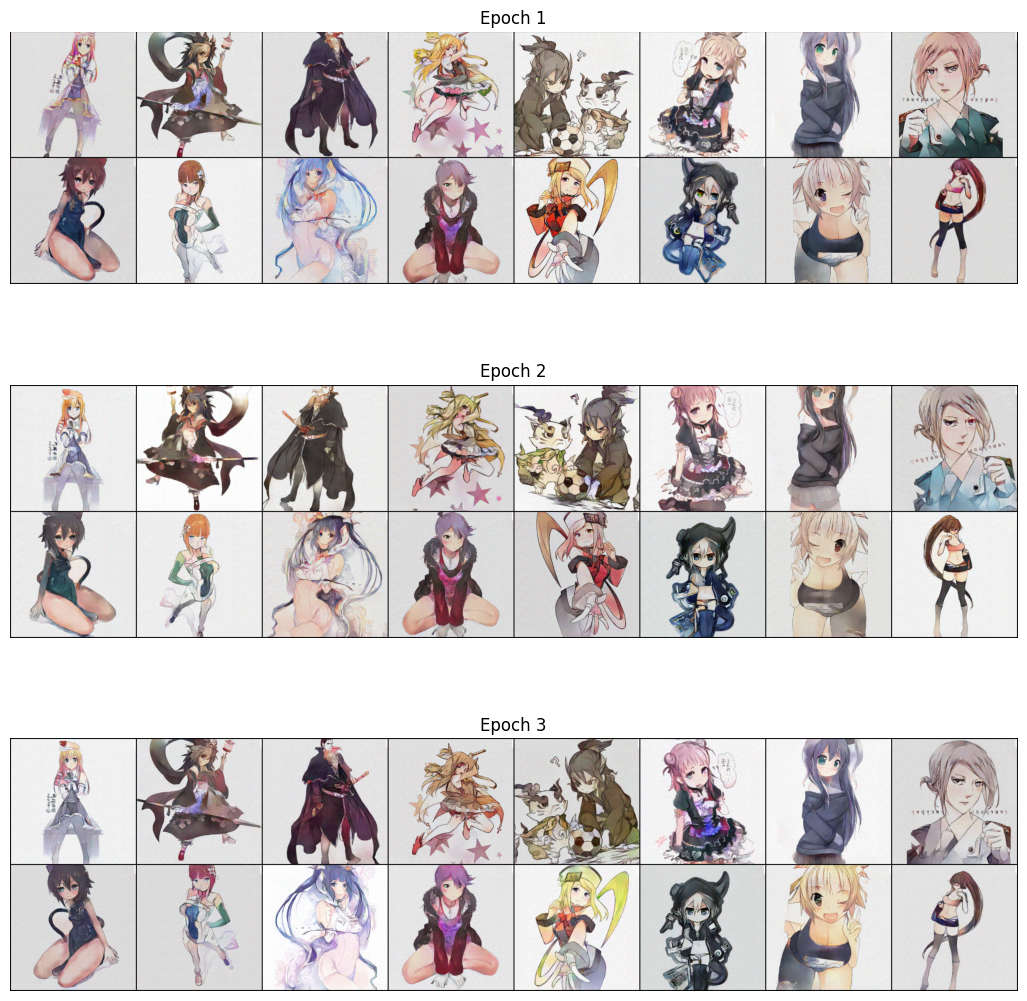

In [18]:
# Visualizes the generated samples across epochs in a single grid.

# visualize list of sample images
fig, axs = plt.subplots(3,1,figsize=(13,13))
[ax.imshow(img) for ax,img in zip(axs.ravel(),imgs)]
[ax.axis('off') for ax in axs.ravel()]
[ax.set_title(f'Epoch {i}') for ax, i in zip(axs.ravel(),range(1,4))];


## 15. Real-World Inference (Testing the Final Model)
Here we provide a simple UI within the notebook. It loads the best Generator weights we've trained and creates an upload button so you can upload your own black-and-white sketch to colorize it!


In [19]:
# --- STEP 11: INFERENCE UI ---
# Loads the best checkpoint and displays an interactive file upload widget for custom sketches.

import torch
from PIL import Image as PILImage
import torchvision.transforms as transforms
import torchvision.utils as vutils
from ipywidgets import FileUpload
from IPython.display import display, Image
import io
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gen = Generator(in_channels=3).to(DEVICE)

# Check multiple locations: Working Directory vs Kaggle Input Dataset
# PREVIOUS_VERSION_DIR, CHECKPOINT_GEN, and FINAL_MODEL are defined in Cell 1
PREVIOUS_GEN = os.path.join(PREVIOUS_VERSION_DIR, "gen.pth.tar")

found = False
if os.path.exists(FINAL_MODEL):
    print(f"[*] Loading Final Generator Model from {FINAL_MODEL}...")
    gen.load_state_dict(torch.load(FINAL_MODEL, map_location=DEVICE))
    found = True
elif os.path.exists(CHECKPOINT_GEN):
    print(f"[*] Loading latest Checkpoint from {CHECKPOINT_GEN}...")
    checkpoint = torch.load(CHECKPOINT_GEN, map_location=DEVICE)
    gen.load_state_dict(checkpoint['state_dict'])
    found = True
elif os.path.exists(PREVIOUS_GEN):
    print(f"[*] Found weights in Kaggle Input! Loading from: {PREVIOUS_GEN}")
    checkpoint = torch.load(PREVIOUS_GEN, map_location=DEVICE)
    # Check if it's a checkpoint dict or a raw state_dict
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        gen.load_state_dict(checkpoint["state_dict"])
    else:
        gen.load_state_dict(checkpoint)
    found = True

if not found:
    print("[WARNING] No trained weights found!")
    print(f"Searched in:\n1. {FINAL_MODEL}\n2. {CHECKPOINT_GEN}\n3. {PREVIOUS_GEN}")
    print("\nTip: Make sure PREVIOUS_VERSION_DIR in Cell 1 matches your Kaggle Input path exactly.")

# gen.eval()  # Kept commented to keep Dropout active for better color variance

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

upload = FileUpload(accept='image/*', multiple=False)
display(upload)

def colorize_image(upload):
    if not upload.value:
        return
    try:
        content = upload.value[0]['content'] if isinstance(upload.value, tuple) else list(upload.value.values())[0]['content']
    except Exception:
        content = upload.value

    img = PILImage.open(io.BytesIO(content)).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = gen(input_tensor)

    vutils.save_image(output, "generated_color.png", normalize=True)
    display(Image("generated_color.png"))
    print("Colored image saved to generated_color.png")

upload.observe(lambda change: colorize_image(upload), names='value')


[*] Loading Final Generator Model from /kaggle/working/cGAN_Colorization_Checkpoints/generator.pth...


FileUpload(value=(), accept='image/*', description='Upload')

### 15.1 Trigger Colorization
Applies the colorization function to the uploaded image.


In [20]:
# Runs the loaded model on the uploaded sketch.

colorize_image(upload)


## 16. Post-Processing: Real-ESRGAN Upscaling
Generators usually output small images (e.g., 256x256). We use an AI Super-Resolution model called Real-ESRGAN to upscale the colorized output safely to 4x its size (1024x1024) while preserving sharp anime edges.


In [21]:
# --- STEP 12: ESRGAN UPSCALING ---
# Initializes the Real-ESRGAN model for high-resolution post-processing.

# Post-Processing: Real-ESRGAN Super-Resolution
# Auto-install missing packages for Kaggle restarts
!pip install -q realesrgan basicsr

import cv2
import numpy as np

# Fix for basicsr vs modern torchvision compatibility
import sys
import torchvision.transforms.functional as TF
sys.modules['torchvision.transforms.functional_tensor'] = TF

try:
    from basicsr.archs.rrdbnet_arch import RRDBNet
    from realesrgan import RealESRGANer

    def load_esrgan(model_path='RealESRGAN_x4plus_anime_6B.pth'):
        model = RRDBNet(
            num_in_ch=3, num_out_ch=3, num_feat=64,
            num_block=6, num_grow_ch=32, scale=4
        )
        return RealESRGANer(
            scale=4, model_path=model_path,
            model=model, tile=0, tile_pad=10, half=DEVICE=='cuda'
        )

    def upscale_image(img_bgr, upsampler, outscale=4):
        output, _ = upsampler.enhance(img_bgr, outscale=outscale)
        return output
        
    # Download the weights automatically if they don't exist
    import os
    if not os.path.exists('RealESRGAN_x4plus_anime_6B.pth'):
        !wget -q https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.2.4/RealESRGAN_x4plus_anime_6B.pth

    print("Real-ESRGAN initialized.")
except Exception as e:
    print(f"Failed to initialize Real-ESRGAN. Error details: {e}")


Real-ESRGAN initialized.


In [22]:
!pip install -q albumentations==1.3.1
!pip install -q realesrgan basicsr diffusers transformers accelerate


## 17. Post-Processing: Stable Diffusion Refinement
*(Optional)* We can use an `img2img` pipeline via Stable Diffusion to further refine the shapes and smooth out colors generated by our cGAN model for a completely flawless look.


In [23]:
# --- STEP 13: DIFFUSION REFINEMENT ---
# (Optional) Img2Img stable diffusion wrapper to refine visual artifacts.

# Post-Processing: Diffusion Model Guided Refinement (img2img)
# Note: You may need to run `pip install diffusers transformers accelerate`
try:
    from diffusers import StableDiffusionImg2ImgPipeline
    from PIL import Image

    def refine_with_diffusion(
        image_path,
        prompt="anime character, vibrant colors, high quality",
        strength=0.35,
        guidance_scale=7.5
    ):
        pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=torch.float16 if DEVICE=='cuda' else torch.float32
        ).to(DEVICE)
        
        init_image = Image.open(image_path).convert("RGB")
        init_image = init_image.resize((512, 512))
        
        result = pipe(
            prompt=prompt,
            image=init_image,
            strength=strength,
            guidance_scale=guidance_scale,
            num_inference_steps=50,
        ).images[0]
        
        return result
    print("Diffusion model refinement initialized.")
except ImportError:
    print("Please `pip install diffusers transformers accelerate` to use Diffusion Refinement.")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Diffusion model refinement initialized.


## 18. Post-Processing: Color Transfer
If the generated image has good shading but you want different vibes, this Reinhard Histogram Color Transfer algorithm shifts the color palette of our image to match any reference image.


In [24]:
# --- STEP 14: REINHARD COLOR TRANSFER ---
# (Optional) Algorithm to swap the generated color distribution with a reference image's colors.

# Post-Processing: Histogram-Based Colour Transfer
import cv2
import numpy as np

def colour_transfer(source_bgr, reference_bgr):
    """
    Transfers the colour distribution of reference to source
    in CIELAB colour space (Reinhard et al., 2001).
    """
    src = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    ref = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    for ch in range(3):
        src_mean, src_std = src[:,:,ch].mean(), src[:,:,ch].std()
        ref_mean, ref_std = ref[:,:,ch].mean(), ref[:,:,ch].std()
        src[:,:,ch] = (src[:,:,ch] - src_mean) * (ref_std / (src_std + 1e-6))
        src[:,:,ch] += ref_mean

    src = np.clip(src, 0, 255).astype(np.uint8)
    return cv2.cvtColor(src, cv2.COLOR_LAB2BGR)


## 19. Final Execution
Here we run the Upscaler on our generated color image and compare the original tiny output against our high-resolution upscaled version using Matplotlib.


In [25]:
# --- STEP 15: UPSCALING EXECUTION ---
# Upscales the final generated image and plots a Before/After comparison.

import cv2
import matplotlib.pyplot as plt

# 1. Initialize the Real-ESRGAN upsampler
upsampler = load_esrgan()

# 2. Read the image you want to upscale (OpenCV reads in BGR format which Real-ESRGAN expects)
# Change this path if you want to upscale a different image
image_path = 'generated_color.png' 
img_bgr = cv2.imread(image_path)

if img_bgr is not None:
    print(f"Upscaling '{image_path}'... This might take a moment.")
    
    # 3. Upscale the image (outscale=4 means 4x resolution)
    upscaled_img_bgr = upscale_image(img_bgr, upsampler, outscale=4)
    
    # 4. Save the high-resolution result
    save_path = 'upscaled_result.png'
    cv2.imwrite(save_path, upscaled_img_bgr)
    print(f"Success! Saved high-res image to '{save_path}'")
    
    # 5. Visualize the Before & After
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    upscaled_rgb = cv2.cvtColor(upscaled_img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    axs[0].imshow(img_rgb)
    axs[0].set_title(f'Original ({img_rgb.shape[1]}x{img_rgb.shape[0]})')
    axs[0].axis('off')
    
    axs[1].imshow(upscaled_rgb)
    axs[1].set_title(f'Upscaled ({upscaled_rgb.shape[1]}x{upscaled_rgb.shape[0]})')
    axs[1].axis('off')
    plt.show()
else:
    print(f"Error: Could not find image at '{image_path}'")


Error: Could not find image at 'generated_color.png'


[ WARN:0@41987.104] global loadsave.cpp:278 findDecoder imread_('generated_color.png'): can't open/read file: check file path/integrity


In [26]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define paths
source_path = 'generated_color.png' 
reference_path = '/kaggle/input/datasets/impartiall/image2//Gemini_Generated_Image_kwiklqkwiklqkwik.png' # <--- CHANGE THIS to an actual image path you want to steal colors from!

if not os.path.exists(source_path):
    print(f"Error: Source image '{source_path}' not found!")
elif not os.path.exists(reference_path):
    print(f"Error: Reference image '{reference_path}' not found! Please upload one or change the path.")
else:
    # 2. Load images in BGR format
    source_bgr = cv2.imread(source_path)
    reference_bgr = cv2.imread(reference_path)
    
    print("1. Applying Histogram Colour Transfer...")
    # 3. Apply Colour Transfer
    color_matched_bgr = colour_transfer(source_bgr, reference_bgr)
    
    # Save the intermediate step just in case
    cv2.imwrite('color_matched_only.png', color_matched_bgr)
    
    print("2. Enhancing with Real-ESRGAN... (this may take a moment)")
    # 4. Initialize ESRGAN
    upsampler = load_esrgan()
    
    # 5. Upscale the color-matched image
    final_upscaled_bgr = upscale_image(color_matched_bgr, upsampler, outscale=4)
    
    # Save the final result
    final_path = 'final_enhanced_output.png'
    cv2.imwrite(final_path, final_upscaled_bgr)
    print(f"Success! Saved final enhanced image to '{final_path}'")
    
    # 6. Visualize the pipeline
    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    
    # Convert BGR to RGB for matplotlib
    axs[0].imshow(cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB))
    axs[0].set_title('Original GAN Output')
    axs[0].axis('off')
    
    axs[1].imshow(cv2.cvtColor(color_matched_bgr, cv2.COLOR_BGR2RGB))
    axs[1].set_title('After Colour Transfer')
    axs[1].axis('off')
    
    axs[2].imshow(cv2.cvtColor(final_upscaled_bgr, cv2.COLOR_BGR2RGB))
    axs[2].set_title(f'Real-ESRGAN Upscaled ({final_upscaled_bgr.shape[1]}x{final_upscaled_bgr.shape[0]})')
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()


Error: Source image 'generated_color.png' not found!
